In [24]:
import os
import pandas as pd

os.makedirs("data_fifa20", exist_ok=True)

csv_path = "data_fifa20/players_20.csv"

if not os.path.exists(csv_path):
    os.system("kaggle datasets download stefanoleone992/fifa-21-complete-player-dataset -f players_20.csv -p data_fifa20 --unzip")
    print("Download complete.")
else:
    print("File already exists, skipping download.")

File already exists, skipping download.


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

identifier = "short_name"
target = "preferred_foot"
features = [
    "age", "height_cm", "weight_kg",
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys",
    "skill_dribbling", "skill_curve", "skill_long_passing", "skill_ball_control",
    "movement_acceleration", "movement_sprint_speed", "movement_agility",
    "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina", "power_strength",
    "mentality_aggression", "mentality_positioning", "mentality_vision",
    "defending_standing_tackle",
    "goalkeeping_diving", "goalkeeping_reflexes"
]

# Load only necessary columns
df = pd.read_csv("data_fifa20/players_20.csv", usecols=[identifier, target] + features, low_memory=False)

# Drop only rows where target is missing, reset index
df = df.dropna(subset=[target]).copy().reset_index(drop=True)

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

print(f"Shape: {df.shape}")
df.head()

Shape: (18483, 35)


,short_name,age,height_cm,weight_kg,preferred_foot,pace,shooting,passing,dribbling,defending,...,power_shot_power,power_jumping,power_stamina,power_strength,mentality_aggression,mentality_positioning,mentality_vision,defending_standing_tackle,goalkeeping_diving,goalkeeping_reflexes
0,L. Messi,32.0,170.0,72.0,Left,87.0,92.0,92.0,96.0,39.0,...,86.0,68.0,75.0,68.0,48.0,94.0,94.0,37.0,6.0,8.0
1,Cristiano Ronaldo,34.0,187.0,83.0,Right,90.0,93.0,82.0,89.0,35.0,...,95.0,95.0,85.0,78.0,63.0,95.0,82.0,32.0,7.0,11.0
2,Neymar Jr,27.0,175.0,68.0,Right,91.0,85.0,87.0,95.0,32.0,...,80.0,61.0,81.0,49.0,51.0,87.0,90.0,26.0,9.0,11.0
3,J. Oblak,26.0,188.0,87.0,Right,69.0,54.0,58.0,64.0,56.0,...,59.0,78.0,41.0,78.0,34.0,11.0,65.0,12.0,87.0,89.0
4,E. Hazard,28.0,175.0,74.0,Right,91.0,83.0,86.0,94.0,35.0,...,82.0,56.0,84.0,63.0,54.0,87.0,89.0,27.0,11.0,8.0


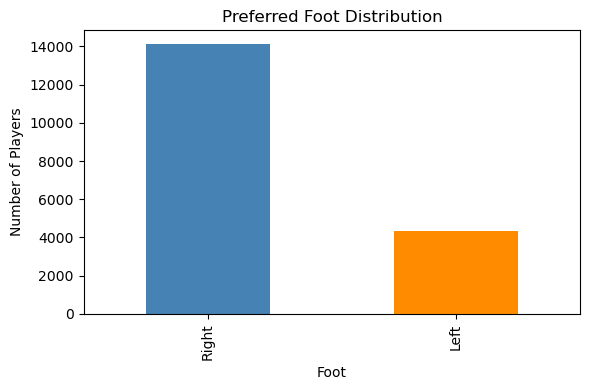

preferred_foot
Right    14128
Left      4355
Name: count, dtype: int64


In [26]:
# Target distribution
plt.figure(figsize=(6, 4))
df[target].value_counts().plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title("Preferred Foot Distribution")
plt.xlabel("Foot")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

print(df[target].value_counts())

In [27]:
# Null values check
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")

short_name                    0
age                           0
height_cm                     0
weight_kg                     0
preferred_foot                0
pace                          0
shooting                      0
passing                       0
dribbling                     0
defending                     0
physic                        0
attacking_crossing            0
attacking_finishing           0
attacking_heading_accuracy    0
attacking_short_passing       0
attacking_volleys             0
skill_dribbling               0
skill_curve                   0
skill_long_passing            0
skill_ball_control            0
movement_acceleration         0
movement_sprint_speed         0
movement_agility              0
movement_reactions            0
movement_balance              0
power_shot_power              0
power_jumping                 0
power_stamina                 0
power_strength                0
mentality_aggression          0
mentality_positioning         0
mentalit

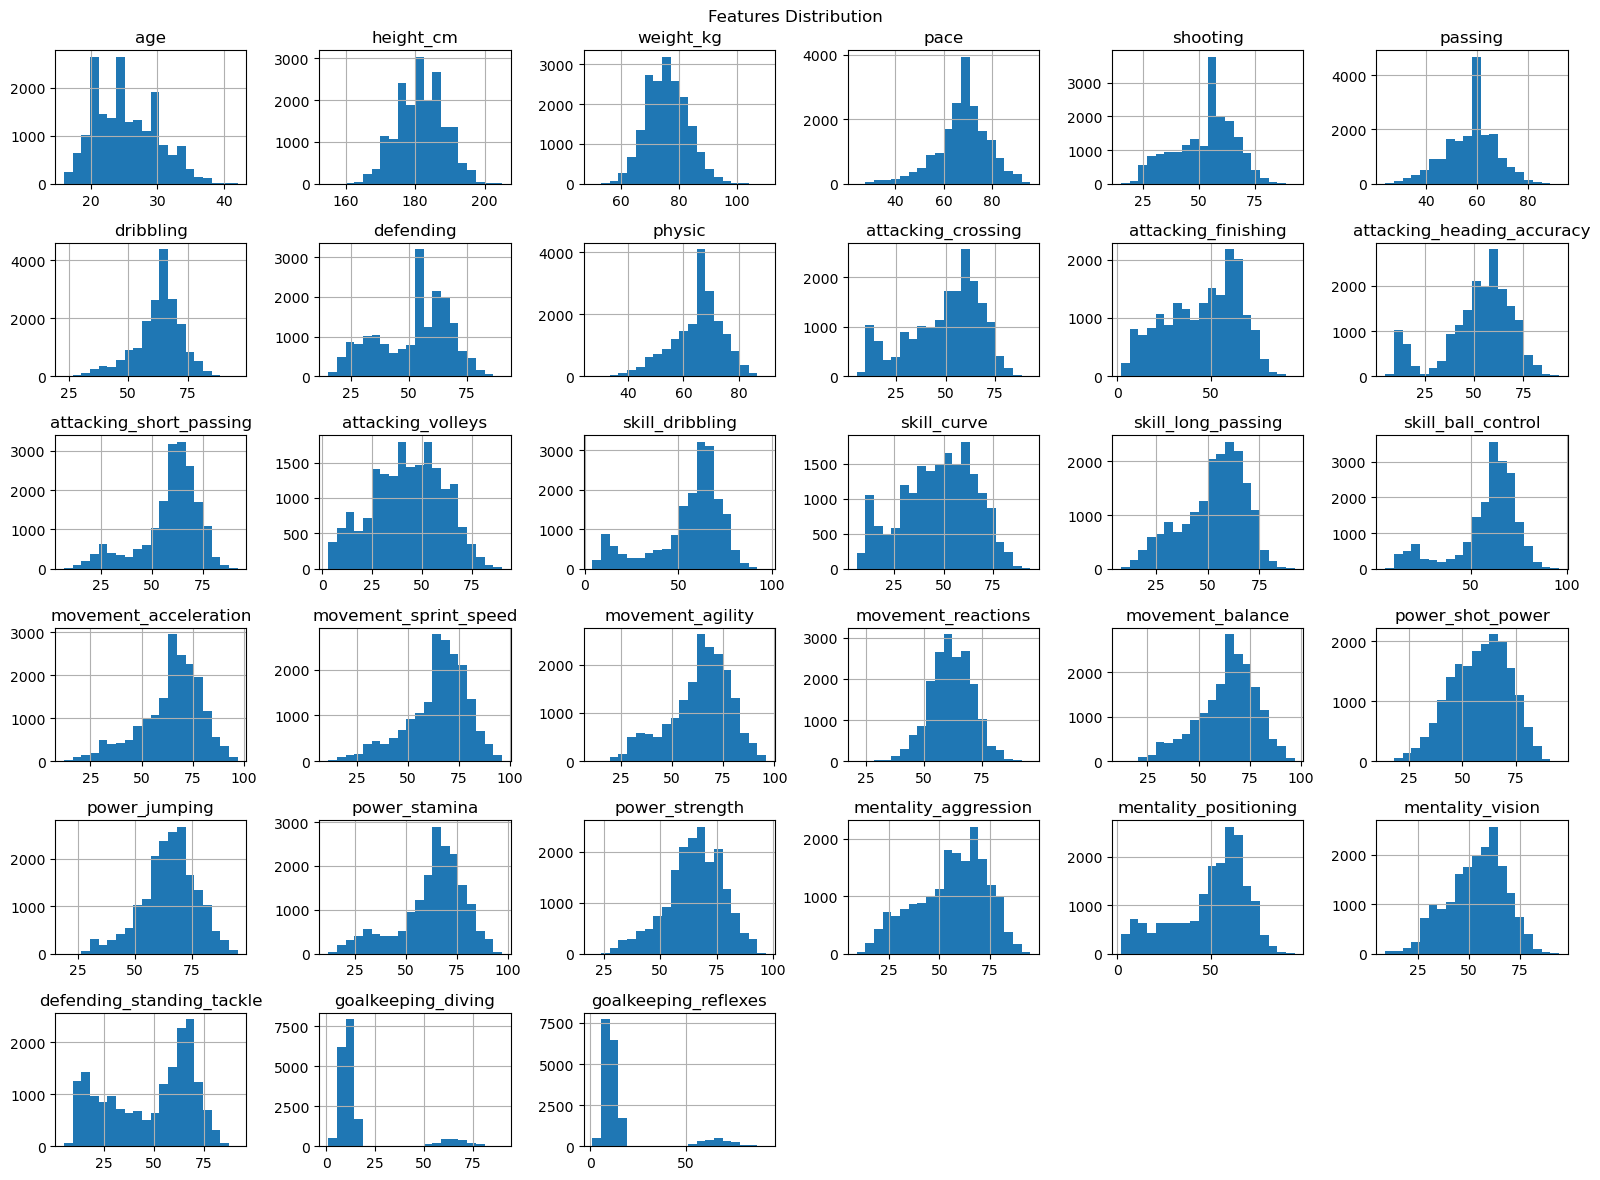

In [28]:
# Features distribution
df[features].hist(bins=20, figsize=(16, 12))
plt.suptitle("Features Distribution")
plt.tight_layout()
plt.show()

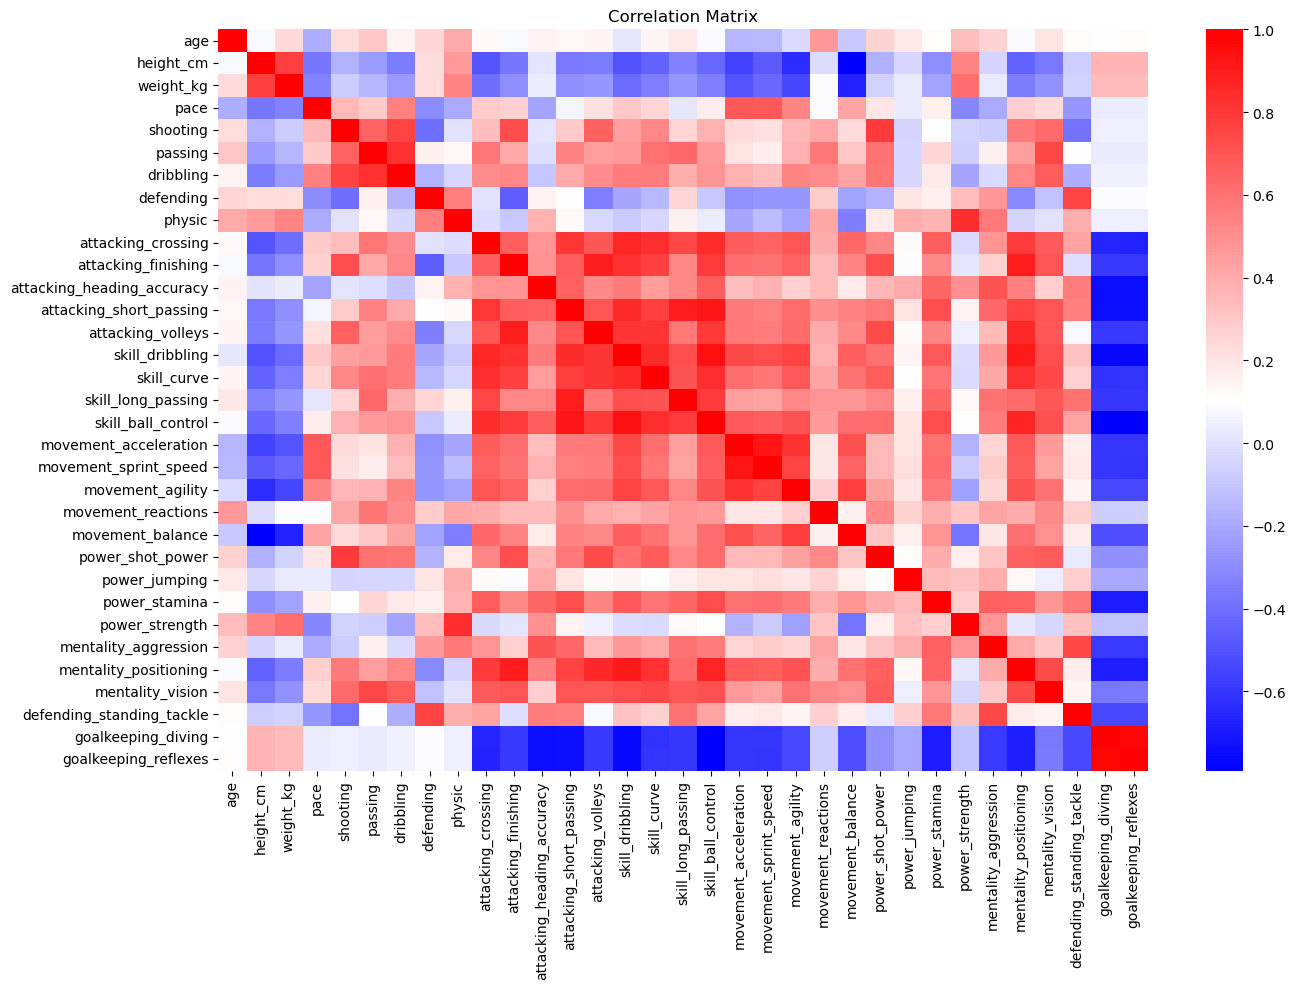

In [29]:
# Correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df[features].corr(), cmap='bwr', annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(df[target])
X = df[features].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Classes: {le.classes_}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Classes: ['Left' 'Right']
Train: (14786, 33) | Test: (3697, 33)


In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Test different hidden layer sizes
hidden_configs = [(32,), (64,), (128,), (64, 32), (128, 64)]
results_nodes = []

for config in hidden_configs:
    bpn = MLPClassifier(
        hidden_layer_sizes=config,
        activation='relu',
        learning_rate_init=0.01,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_nodes.append({"Hidden Layers": str(config), "Accuracy (%)": round(acc * 100, 2)})
    print(f"Config {config} → Accuracy: {acc:.4f}")

df_nodes = pd.DataFrame(results_nodes)
print("\n", df_nodes)

Config (32,) → Accuracy: 0.7712
Config (64,) → Accuracy: 0.7455
Config (128,) → Accuracy: 0.7173
Config (64, 32) → Accuracy: 0.7311
Config (128, 64) → Accuracy: 0.7198

   Hidden Layers  Accuracy (%)
0         (32,)         77.12
1         (64,)         74.55
2        (128,)         71.73
3      (64, 32)         73.11
4     (128, 64)         71.98


In [32]:
# Test different learning rates
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
results_lr = []

for lr in learning_rates:
    bpn = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    bpn.fit(X_train, y_train)
    acc = accuracy_score(y_test, bpn.predict(X_test))
    results_lr.append({"Learning Rate": lr, "Accuracy (%)": round(acc * 100, 2)})
    print(f"LR {lr} → Accuracy: {acc:.4f}")

df_lr = pd.DataFrame(results_lr)
print("\n", df_lr)

LR 0.001 → Accuracy: 0.7144
LR 0.01 → Accuracy: 0.7311
LR 0.05 → Accuracy: 0.7695
LR 0.1 → Accuracy: 0.7660
LR 0.3 → Accuracy: 0.7660

    Learning Rate  Accuracy (%)
0          0.001         71.44
1          0.010         73.11
2          0.050         76.95
3          0.100         76.60
4          0.300         76.60


In [35]:
from sklearn.metrics import classification_report

# Best model
best_bpn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)
best_bpn.fit(X_train, y_train)
y_pred = best_bpn.predict(X_test)

print(" Classification Report ")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Recalling
sample = X_test[0].reshape(1, -1)
prediction = le.inverse_transform(best_bpn.predict(sample))
print(f"Recalling example → Predicted foot: {prediction[0]}")
print(f"Actual foot:         {le.inverse_transform([y_test[0]])[0]}")

 Classification Report 
              precision    recall  f1-score   support

        Left       0.39      0.28      0.33       865
       Right       0.80      0.87      0.83      2832

    accuracy                           0.73      3697
   macro avg       0.60      0.57      0.58      3697
weighted avg       0.70      0.73      0.71      3697

Recalling example → Predicted foot: Right
Actual foot:         Left


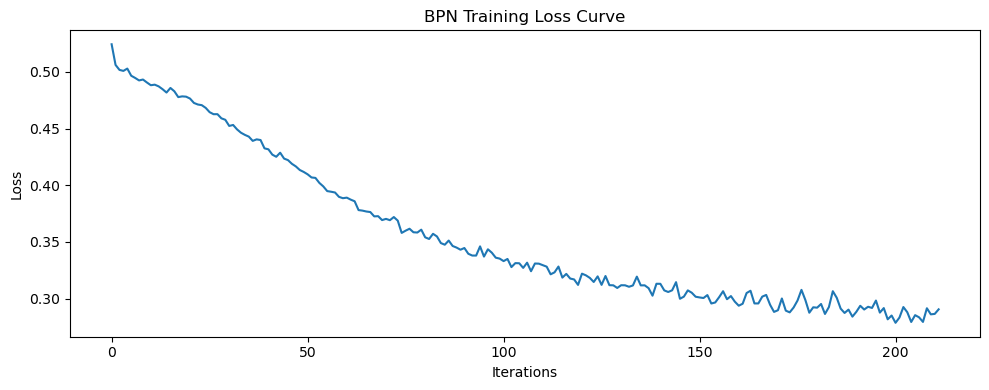

In [34]:
# Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(best_bpn.loss_curve_)
plt.title("BPN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()